In [ ]:
!git clone https://git.wur.nl/dijk097/ml2023_projectmbf.git data


fatal: destination path 'data' already exists and is not an empty directory.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
data = pd.read_csv('data/data_labeled_fixed.csv')
data.columns = data.columns.str.replace("-", "")

In [ ]:
#dataweek1 = data.drop(data.columns[-2],axis=1)

In [ ]:
!pip install -q --upgrade pip matplotlib graphviz scikit-learn

import pandas as pd
!pip install --upgrade scikit-learn

from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
#dataweek1.head()

dataset for classification

In [ ]:
X = data.drop(data.columns[-2:],axis=1)
X=X[X.columns[X.mean()>2]] #additional code
y = (data['CLASS'] == 'Rod Bipolar').astype(int)
print(X.shape)
print(y.shape)


(3724, 22)
(3724,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)#30% of the data will be used for testing, and 70% will be used for training
# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2606, 22)
X_test shape: (1118, 22)
y_train shape: (2606,)
y_test shape: (1118,)


Create and train a Decision Tree model
using DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a DecisionTreeClassifier object with random_state 0
tree_classifier = DecisionTreeClassifier(random_state=0)

#Train with the training dataset X_train, y_train with .fit()
tree_classifier.fit(X_train, y_train)

#Predict the response y_pred for the test dataset X_test with .predict()
y_pred = tree_classifier.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Model Accuracy, how often is the classifier correct?
print("Accuracy:", accuracy_score(y_test, y_pred))

# Implement your own accuracy metric by calculating the average of correct predictions
# You can test if elements of vectors A and B are equal with "A==B" and calculate the average of all elements in a vector with .mean()
own_accuracy = (y_test == y_pred).mean()
print("Own Accuracy:", own_accuracy)

# TODO: Print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.9821109123434705
Own Accuracy: 0.9821109123434705
Confusion Matrix:
[[970   8]
 [ 12 128]]


calculate sensitivity and specificity from a confusion matrix:

In [ ]:
# Calculate Sensitivity (True Positive Rate or Recall)
sensitivity = conf_matrix[1][1] / (conf_matrix[1][1] + conf_matrix[1][0])

# Calculate Specificity (True Negative Rate)
specificity = conf_matrix[0][0] / (conf_matrix[0][0] + conf_matrix[0][1])

# Print the results
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


Sensitivity: 0.9143
Specificity: 0.9918


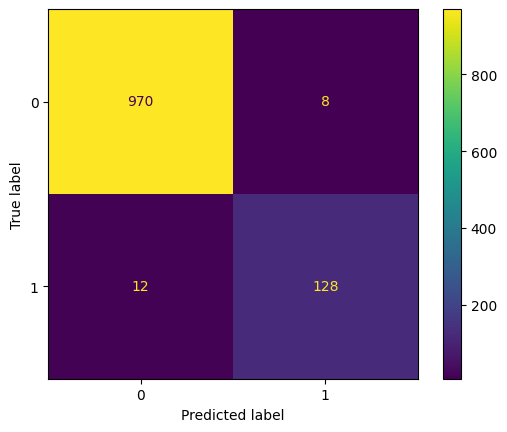

In [ ]:
# TODO Import the confusion_matrix function and the ConfusionMatrixDisplay class from scikit learn metrics

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(cm).plot()

Visualizing Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier


# TODO: Print the depth of the tree
tree_depth = tree_classifier.tree_.max_depth
print("Tree Depth:", tree_depth)

# Assuming pima is a DecisionTreeClassifier model

# TODO: Print the depth of the tree
tree_depth = tree_classifier.get_depth()
print("Tree Depth:", tree_depth)

# TODO: Print the number of leaves in the tree
num_leaves = tree_classifier.get_n_leaves()
print("Number of Leaves:", num_leaves)


Tree Depth: 11
Tree Depth: 11
Number of Leaves: 49


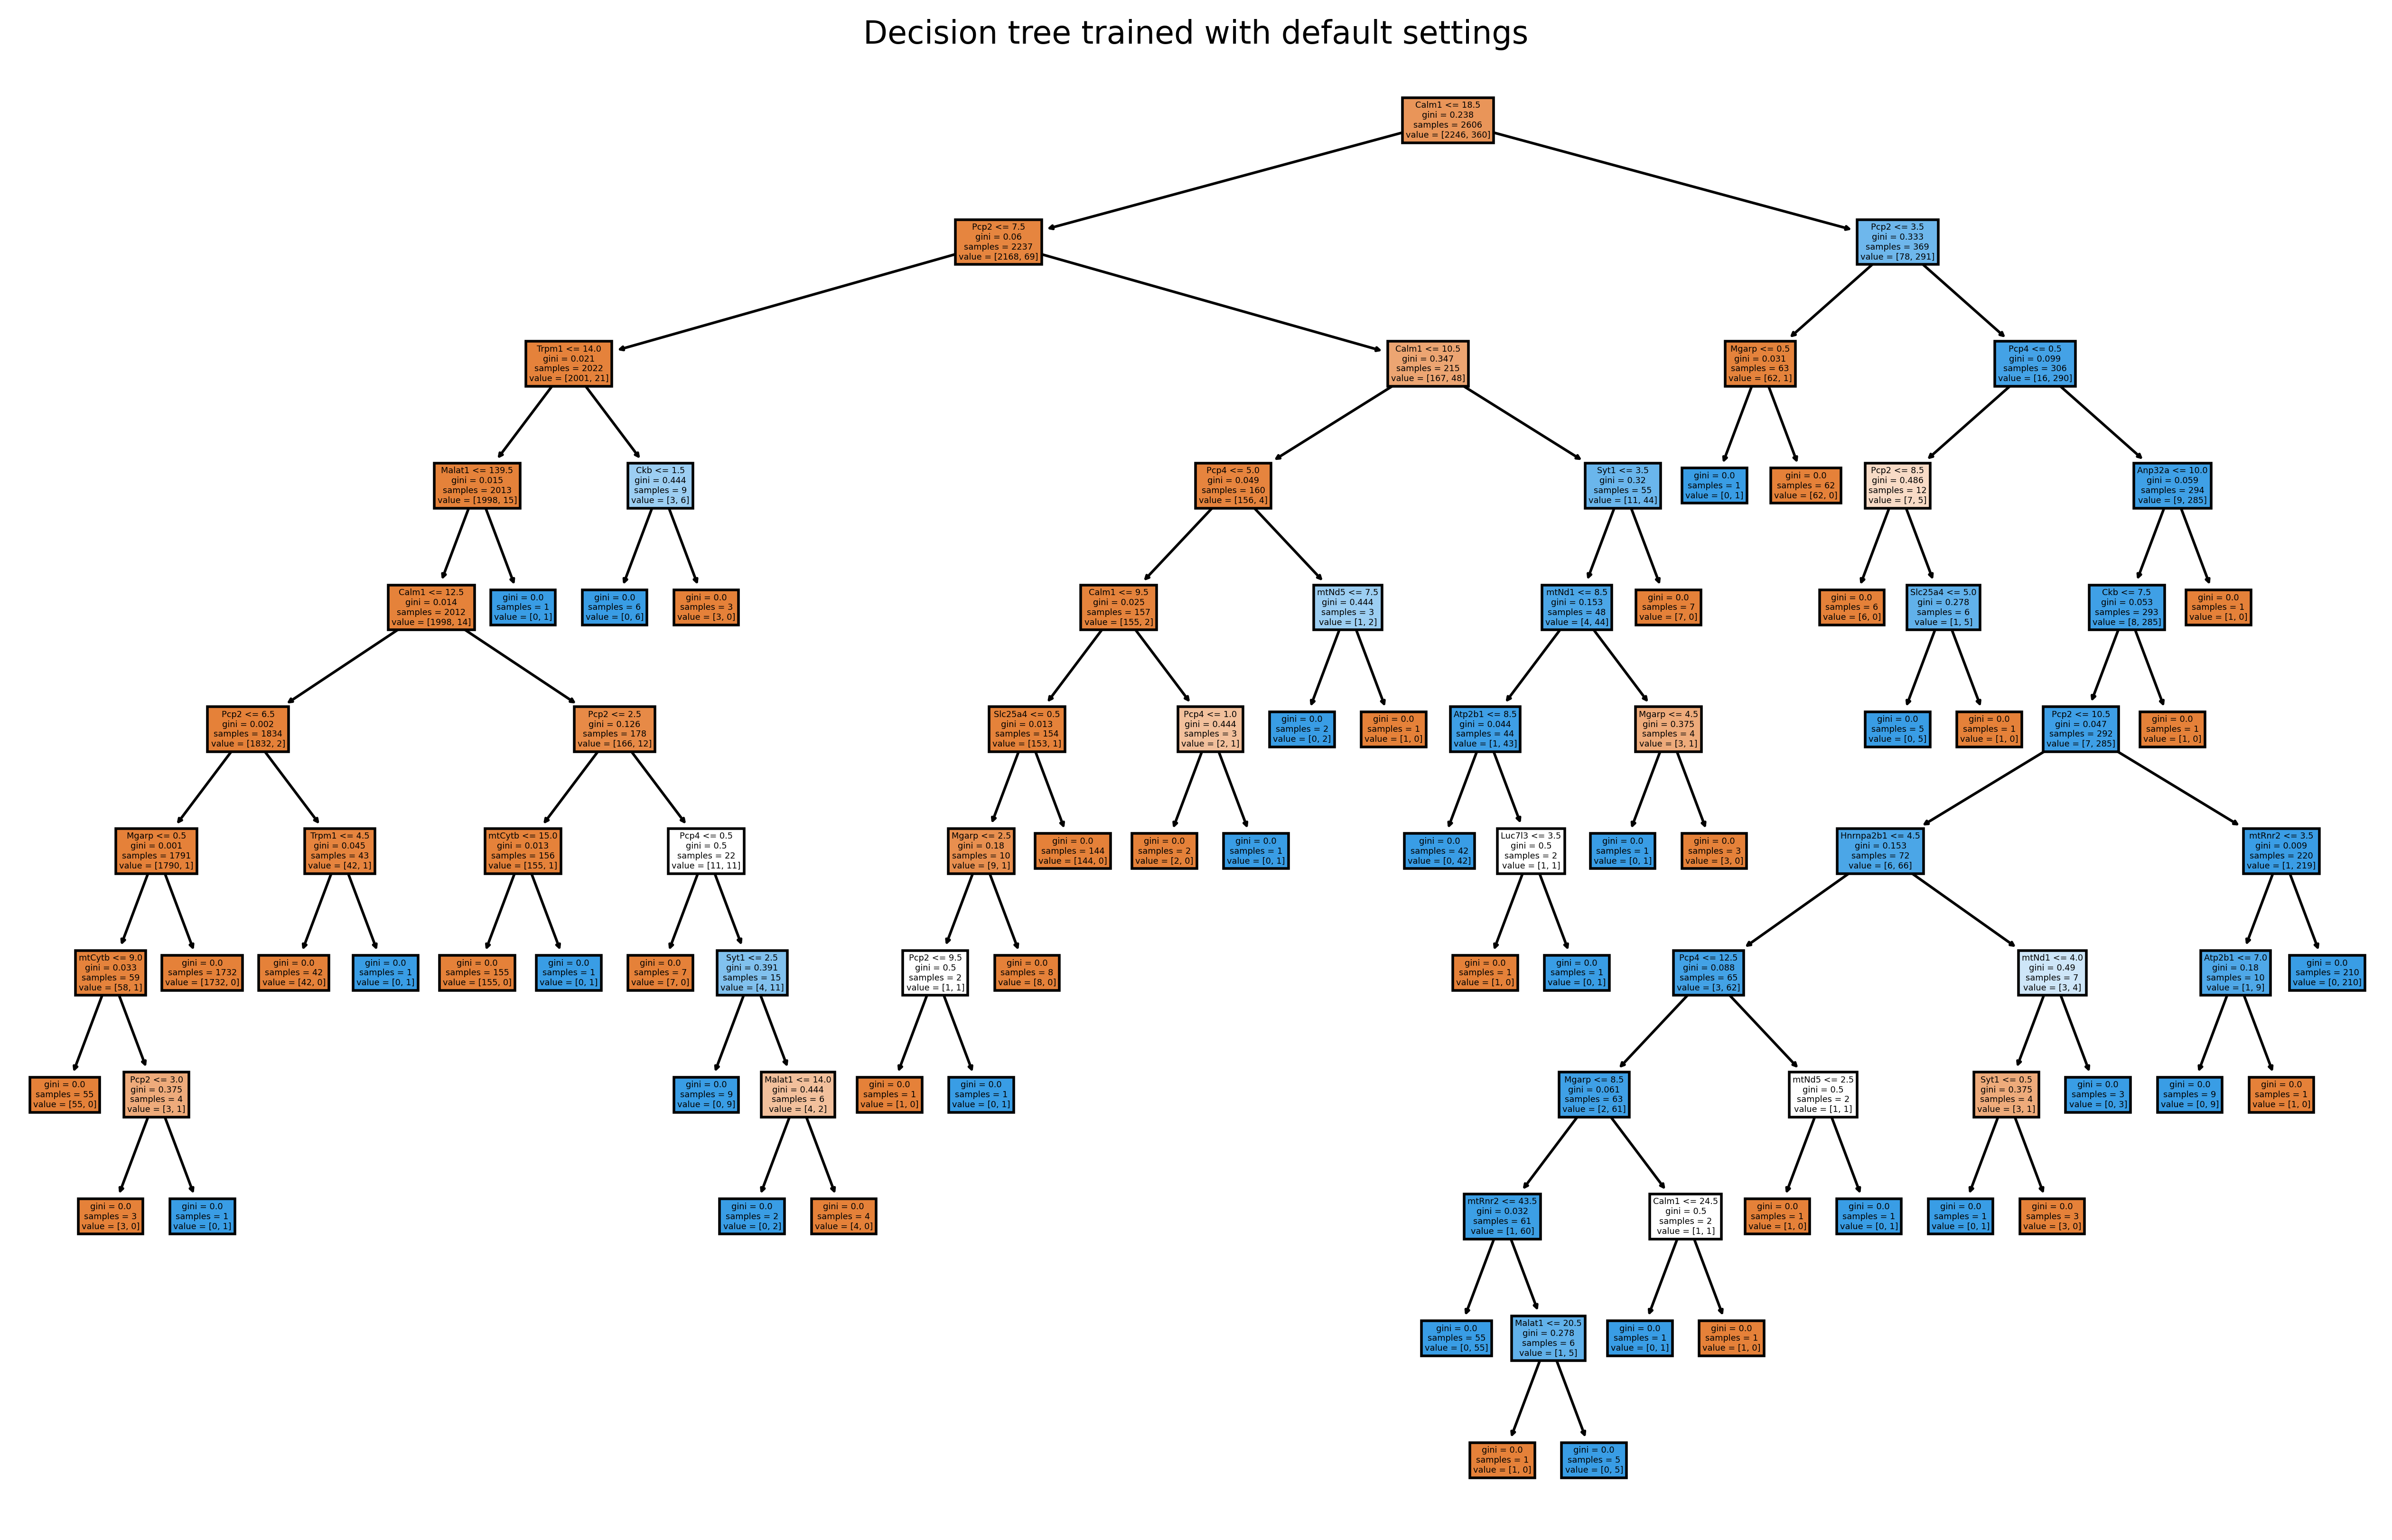

In [ ]:
plt.figure(figsize=(16,10), dpi=400)
tree.plot_tree(tree_classifier, filled=True, feature_names=X_train.columns)
plt.title("Decision tree trained with default settings")
plt.show()

In [ ]:

# Print the feature importance
feature_importance = tree_classifier.feature_importances_

# Get the names of the input features
feature_names = X.columns  # Replace X with the actual input features

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Print the DataFrame
print("Feature Importance:")
print(feature_importance_df)

Feature Importance:
      Feature  Importance
0      Anp32a    0.003039
1       Aplp2    0.000000
2      Atp2b1    0.004439
3       Calm1    0.670376
4         Ckb    0.009506
5       Gng13    0.000000
6   Hnrnpa2b1    0.002979
7      Luc7l3    0.001612
8      Malat1    0.010160
9        Meg3    0.000000
10      Mgarp    0.008391
11       Pcp2    0.201631
12       Pcp4    0.027200
13       Scg2    0.000000
14    Slc25a4    0.002987
15       Syt1    0.024119
16      Trpm1    0.015697
17      Ttyh1    0.000000
18     mtCytb    0.003953
19      mtNd1    0.009359
20      mtNd5    0.003760
21     mtRnr2    0.000792


In [ ]:
#tree_classifier.feature_importances_


<Axes: xlabel='Importance', ylabel='None'>

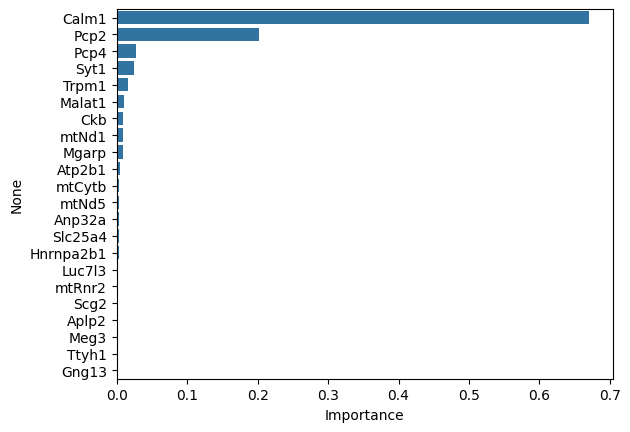

In [ ]:
fi = pd.DataFrame(data=tree_classifier.feature_importances_, index=X.columns, columns =['Importance'])\
.sort_values(by=['Importance'], ascending= False)
# And visualize
sns.barplot(data=fi, x="Importance", y=fi.index)

<Axes: xlabel='Importance', ylabel='None'>

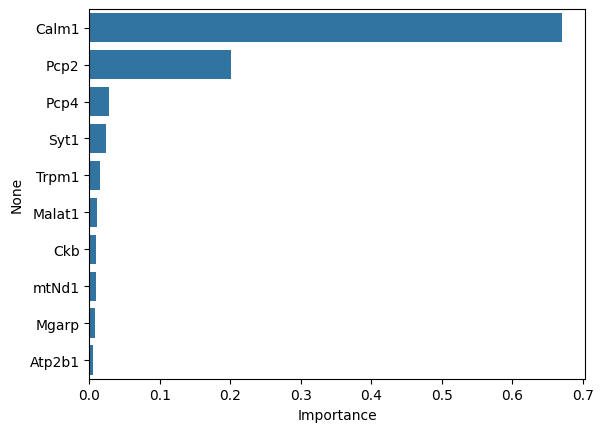

In [ ]:
# Fit your model (if not done already)
tree_classifier.fit(X_train, y_train)

# Add feature importance to a dataframe, together with the names of the columns.
# Sort for convenience
fi = pd.DataFrame(data=tree_classifier.feature_importances_, index=X_train.columns, columns=['Importance']) \
    .sort_values(by=['Importance'], ascending=False)

# Get the importance of only the first 10 genes
top_10_genes_importance = fi.head(10)

# Visualize the importance of the top 10 genes
sns.barplot(data=top_10_genes_importance, x="Importance", y=top_10_genes_importance.index)


**Decision** tree prunning

Train Accuracy: 0.9892555640828856
Test Accuracy: 0.9776386404293381


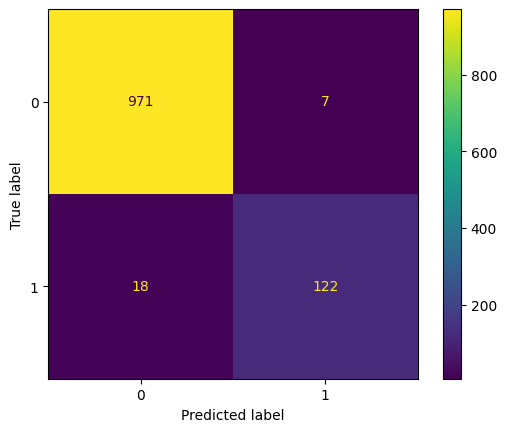

In [ ]:
# Create Decision Tree classifer object
dt2 = DecisionTreeClassifier(max_leaf_nodes = 15, random_state=0)
# Train with the training dataset
dt2.fit(X_train,y_train)
y_pred_train = dt2.predict(X_train)
#Predict the response for test dataset
y_pred = dt2.predict(X_test)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

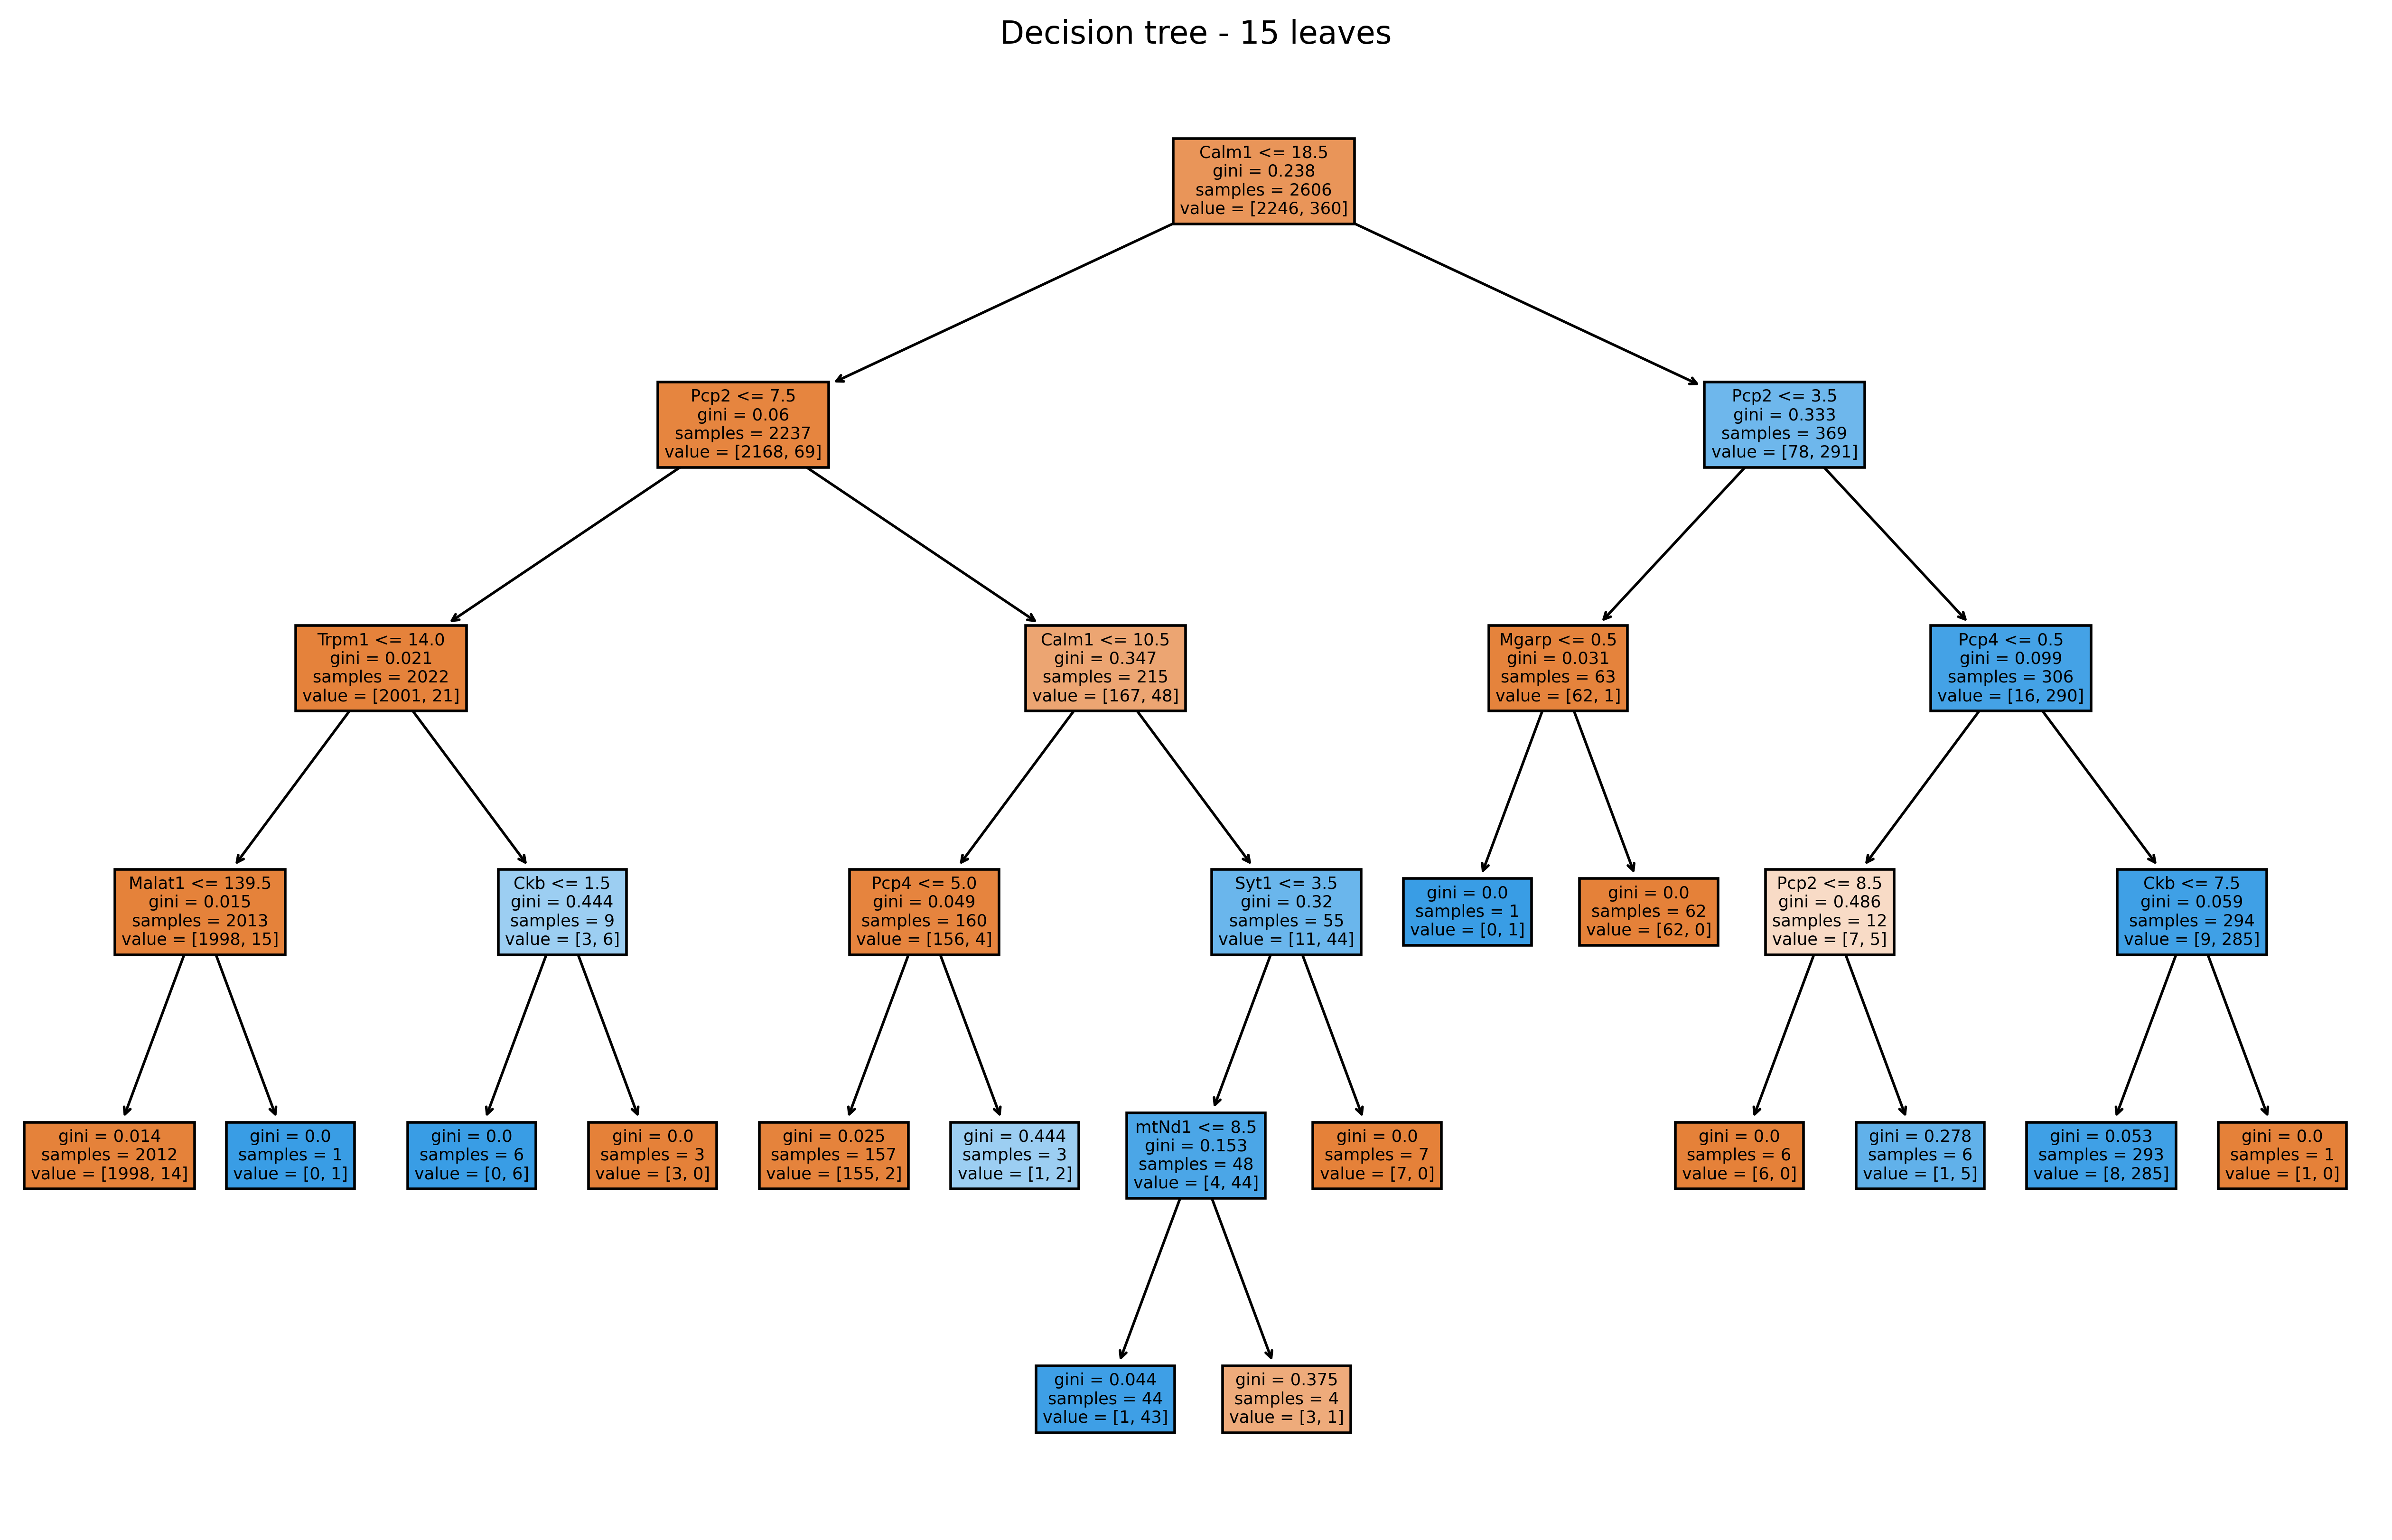

In [ ]:
plt.figure(figsize=(16,10), dpi=400)
tree.plot_tree(dt2, filled=True, feature_names=X_train.columns)
plt.title("Decision tree - 15 leaves")
plt.show()

Hyper-parameter tuning of Decision Trees with Cross-Validation

In [ ]:
results = []

for mtl in range(5, 30):
    # Create Decision Tree classifer object
    dt = DecisionTreeClassifier(max_leaf_nodes = mtl, random_state=0)
    # Train with the training dataset
    dt.fit(X_train,y_train)
    #Predict the response for training and test set
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    #Estimate a performance metric
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    results.append({'leaves':mtl, 'acc_train':acc_train, 'acc_test':acc_test})
    # print("leaves", mtl, "- Training accuracy:", acc_train, " - Test accuracy", acc_test)

results = pd.DataFrame(results)
results

,leaves,acc_train,acc_test
0,5,0.979662,0.981216
1,6,0.982348,0.980322
2,7,0.983500,0.980322
3,8,0.984267,0.978533
4,9,0.985802,0.980322
5,10,0.986953,0.981216
6,11,0.987721,0.979428
7,12,0.988104,0.979428
8,13,0.988488,0.978533
9,14,0.988872,0.977639


<Axes: xlabel='leaves'>

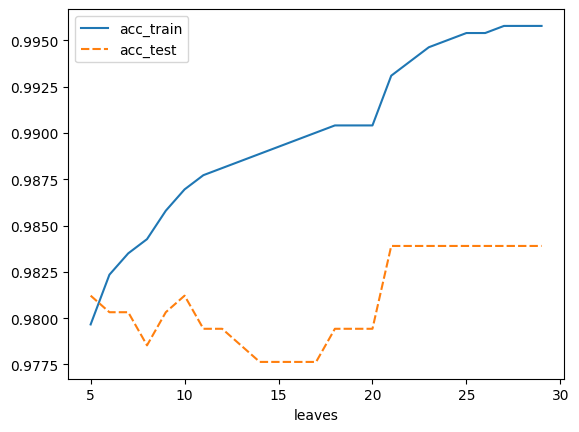

In [ ]:
import seaborn as sns
sns.lineplot(data=results.set_index("leaves"))

Automated Hyperparameter tuning with Sklearn

In [ ]:
from sklearn.model_selection import GridSearchCV
#SOLUTIONEND
# Lets first create a decision tree classifier
dt = DecisionTreeClassifier()
hyperparameters = {'max_leaf_nodes': range(5,30)}

dt_cv = GridSearchCV(dt, hyperparameters,
cv= 10,
verbose = True)
# TODO: fit the GridSearchCV to the X_train, y_train by calling fit on this dt_cv object
# It executes the exhastive search
#SOLUTIONSTART
dt_cv.fit(X_train, y_train)
#SOLUTIONEND
# These variables will be available after the dt_cv object is fitted to the data
print("Best hyperparameters", dt_cv.best_params_)
print("Best score", dt_cv.best_score_)

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best hyperparameters {'max_leaf_nodes': 28}
Best score 0.9811965811965813


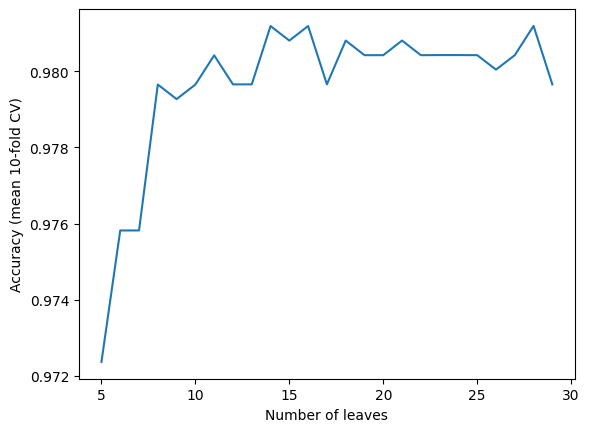

In [ ]:
plt.figure()
sns.lineplot(y= dt_cv.cv_results_["mean_test_score"], x=dt_cv.cv_results_['param_max_leaf_nodes'].data)
plt.xlabel("Number of leaves")
plt.ylabel("Accuracy (mean 10-fold CV)")
plt.show()


Accuracy: 0.981216457960644


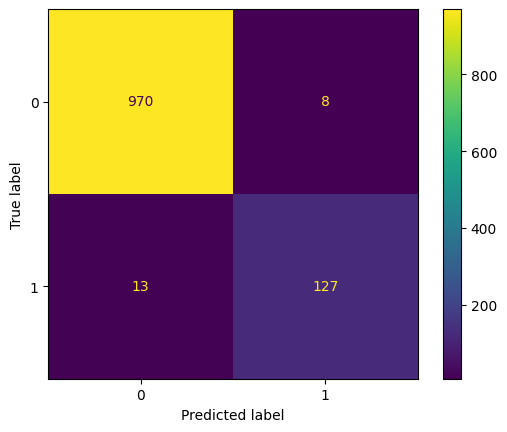

In [ ]:
y_pred = dt_cv.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()


svm classifier

In [ ]:
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("X_train, X_test:", X_train.shape, X_test.shape)
print("y_train, y_test:", y_train.shape, y_test.shape)

X_train, X_test: (2606, 22) (1118, 22)
y_train, y_test: (2606,) (1118,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [ ]:
svm_classifier = SVC(kernel='linear', decision_function_shape='ovo', random_state=42)
svm_classifier.fit(X_train_std, y_train)


SVC(decision_function_shape='ovo', kernel='linear', random_state=42)

In [ ]:
y_pred = svm_classifier.predict(X_test_std)


In [ ]:
# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
#classification_rep = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:\n', conf_matrix)
#print('Classification Report:\n', classification_rep)

Accuracy: 0.9847942754919499
Confusion Matrix:
 [[973   5]
 [ 12 128]]


In [ ]:
#tttttttttttttttttttttttt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for SVC
hyperparameters = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
}

# Create an SVC model
svc_model = SVC()

# Implement GridSearchCV for SVC
svc_cv = GridSearchCV(svc_model, hyperparameters, cv=5, verbose=True, n_jobs=-1)

# Execute the exhaustive search by calling fit
svc_cv.fit(X_train_std, y_train)

# Get the best hyperparameters
best_params = svc_cv.best_params_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Predict with the best model
y_pred_svc = svc_cv.predict(X_test_std)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Hyperparameters: {'C': 1, 'kernel': 'rbf'}


random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
#O Create a Random Forest regressor with 50 trees. use at most 90% of the features, return the OOB score
rf_c = RandomForestClassifier(
n_estimators = 50,
max_features = 0.9,
oob_score = True)

In [ ]:

# TODO fit the model to the training data
#SOLUTIONSTART
rf_c.fit(X_train, y_train)
#SOLUTIONEND
# Evaluate with OOB
print("--OOB--")
print("R^2",rf_c.oob_score_)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

--OOB--
R^2 0.9834996162701458
Accuracy: 0.9848


<Axes: xlabel='Importance', ylabel='None'>

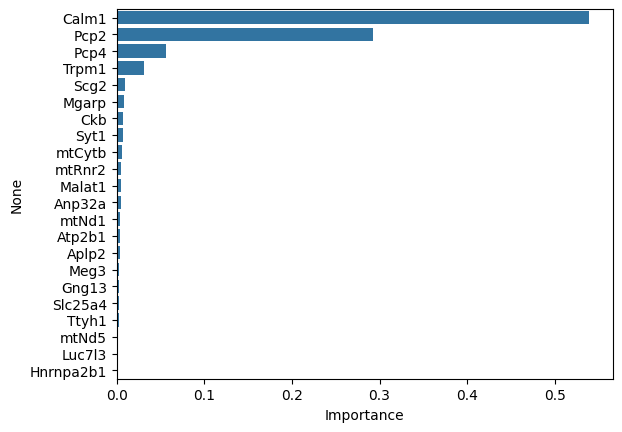

In [ ]:
#Sort for convinience
fi = pd.DataFrame(data=rf_c.feature_importances_, index=X_train.columns, columns = ['Importance'])\
.sort_values(by=['Importance'], ascending= False)
# And visualize
sns.barplot(data=fi, x="Importance", y=fi.index)

<ipython-input-33-c5569b7c9c80>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x="Importance", y=top_features.index, palette='viridis')


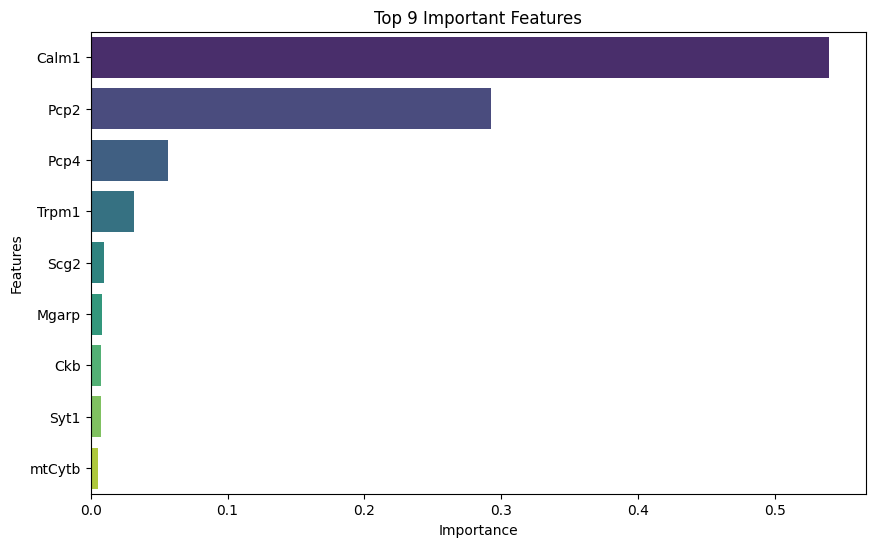

In [ ]:
# Sort the features by importance in descending order
fi_sorted = pd.DataFrame(data=rf_c.feature_importances_, index=X_train.columns, columns=['Importance']) \
    .sort_values(by=['Importance'], ascending=False)

# Select the top 9 features
top_n = 9
top_features = fi_sorted.head(top_n)

# Plot the barplot for the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y=top_features.index, palette='viridis')
plt.title(f'Top {top_n} Important Features')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [ ]:
# TODO evaluate with the test set
#SOLUTIONSTART
y_pred = rf_c.predict(X_test)
#SOLUTIONEND
# Calculate performance metrics
print("--Test--")
print("R^2", r2_score(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

--Test--
R^2 0.8775197195442594
Accuracy: 0.9866


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for Random Forest Classifier
hyperparameters = {
    'n_estimators': [50, 200],# make changes here to get a decen tpoint plot with more than two points
    'max_features': [6, 4]
}

# Create a Random Forest Classifier
#rf_classifier = RandomForestClassifier()

# Implement GridSearchCV for Random Forest Classifier
btr_cv = GridSearchCV(rf_c, hyperparameters, cv=5, verbose=True, n_jobs=-1)

# Execute the exhaustive search by calling fit
btr_cv.fit(X_train, y_train)


Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_features=0.9, n_estimators=50,
                                              oob_score=True),
             n_jobs=-1,
             param_grid={'max_features': [6, 4], 'n_estimators': [50, 200]},
             verbose=True)

In [ ]:
print("Best params", btr_cv.best_params_)
# Evaluate with the test set for the best estimator
y_pred = btr_cv.best_estimator_.predict(X_test)
# Calculate performance metrics
print("R^2", r2_score(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))

Best params {'max_features': 4, 'n_estimators': 200}
R^2 0.861189015483494
MSE 0.01520572450805009


<Axes: xlabel='param_n_estimators', ylabel='mean_test_score'>

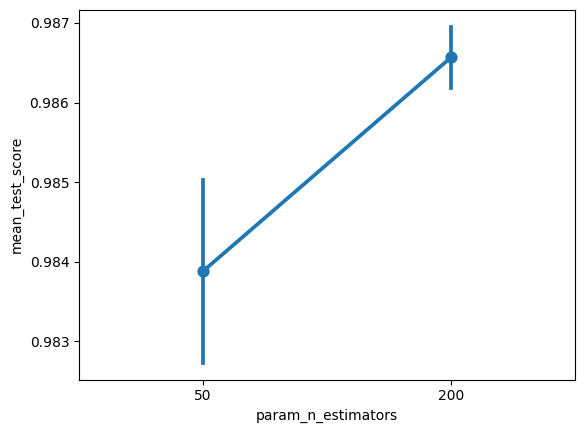

In [ ]:
cv_results = pd.DataFrame(btr_cv.cv_results_)
# Visual of the number of features vs test score
sns.pointplot(cv_results, x="param_n_estimators", y="mean_test_score")

In [ ]:
cv_results


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.311300,0.035793,0.013702,0.007595,6,50,"{'max_features': 6, 'n_estimators': 50}",0.990421,0.980806,0.982726,0.982726,0.988484,0.985032,0.003727,3
1,1.995766,0.286511,0.039176,0.011567,6,200,"{'max_features': 6, 'n_estimators': 200}",0.992337,0.982726,0.988484,0.976967,0.990403,0.986183,0.005619,2
2,0.316325,0.095086,0.012576,0.005254,4,50,"{'max_features': 4, 'n_estimators': 50}",0.986590,0.980806,0.980806,0.978887,0.986564,0.982731,0.003218,4
3,0.944342,0.111416,0.025370,0.003777,4,200,"{'max_features': 4, 'n_estimators': 200}",0.990421,0.982726,0.988484,0.980806,0.992322,0.986952,0.004447,1


best model is model 1 , based on rank_test_score

Decision Trees - Part B

### *Fitting* **Regression** Trees

In [ ]:
!pip install -q --upgrade pip matplotlib graphviz scikit-learn
import pandas as pd
from sklearn.metrics import confusion_matrix, mean_squared_error,mean_absolute_percentage_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
import seaborn as sns
%matplotlib inline


data set for regression

In [ ]:
#X = data.drop(data.columns[-2:],axis=1)
feature_cols = ['Acin1', 'Actb', 'Agap1', 'Ahi1', 'Akap11', 'Akap9', 'Aldoa', 'Aldoc', 'Ankrd12', 'Anp32a', 'Anp32e', 'Aplp1', 'Aplp2', 'Apoe', 'App', 'Arglu1', 'Arl3', 'Arl6ip1', 'Arpc2', 'Atp1a3', 'Atp1b2', 'Atp2b1', 'Atp5a1', 'Atp5b', 'Atp5c1', 'Atp5d', 'Atp5f1', 'Atp5g3', 'Atp5h', 'Atp5j', 'Atp5j2', 'Atp5k', 'Atp5o', 'Atp6v0a1', 'Atp6v0b', 'Atp6v0e2', 'Atp6v1a', 'Atp6v1b2', 'Atp6v1d', 'Atp6v1e1', 'Atpif1', 'Atrx', 'Atxn7l3b', 'B3galt2', 'BC030499', 'Baz2b', 'Bclaf1', 'Bex2', 'Bsg', 'Cabp1', 'Cabp5', 'Cacna2d3', 'Cacna2d4', 'Cadm1', 'Cadps', 'Calm2', 'Calm3', 'Calr', 'Camk2b', 'Canx', 'Car10', 'Car2', 'Car8', 'Cbx1', 'Ccdc88a', 'Cck', 'Ccng1', 'Cct6a', 'Cdc42', 'Cdh8', 'Cdk11b', 'Celf2', 'Celf4', 'Cfap36', 'Cfdp1', 'Chchd10', 'Chchd2', 'Chd4', 'Chga', 'Chgb', 'Cisd1', 'Ckb', 'Cltb', 'Cnbp', 'Cox4i1', 'Cox5a', 'Cox6a1', 'Cox6b1', 'Cox6c', 'Cox7a2', 'Cox7b', 'Cox8a', 'Cpe', 'Cplx3', 'Csnk1a1', 'Ctbp2', 'Dbp', 'Ddx17', 'Ddx5', 'Dnaja1', 'Dnajc8', 'Dynll2', 'Dynlrb1', 'E130218I03Rik', 'Ebf1', 'Edf1', 'Eef2', 'Eid1', 'Eif1', 'Eif3a', 'Eif3c', 'Eif4g2', 'Eif5b', 'Eno2', 'Fam169a', 'Fam171b', 'Fam19a3', 'Fezf1', 'Fezf2', 'Fkbp3', 'Frmd3', 'Fth1', 'Fubp1', 'Fus', 'G3bp2', 'Gabra1', 'Gabrg2', 'Gabrr2', 'Gas5', 'Ghitm', 'Gls', 'Gm37583', 'Gm4792', 'Gnao1', 'Gnas', 'Gnb2l1', 'Gnb3', 'Gng13', 'Gng3', 'Gngt1', 'Gngt2', 'Golga4', 'Gpr179', 'Gprasp1', 'Gria2', 'Grik1', 'Grm6', 'Gsg1', 'Gsk3b', 'Gucy1a3', 'Gucy1b3', 'Guk1', 'H2afy', 'H3f3b', 'Hif1a', 'Hist3h2a', 'Hist3h2ba', 'Hlf', 'Hmgn1', 'Hmgn3', 'Hnrnpa2b1', 'Hnrnpab', 'Hnrnpc', 'Hnrnpd', 'Hnrnpdl', 'Hnrnph1', 'Hnrnpk', 'Hnrnpm', 'Hook1', 'Hp1bp3', 'Hsbp1', 'Hsp90aa1', 'Hsp90ab1', 'Hsp90b1', 'Hspa5', 'Ift20', 'Ik', 'Ip6k2', 'Irx3', 'Irx6', 'Isl1', 'Itm2b', 'Itm2c', 'Kcng4', 'Kcnma1', 'Kif1b', 'Kif21a', 'Klc1', 'Kmt2e', 'Ktn1', 'Laptm4b', 'Lbh', 'Ldha', 'Lhx4', 'Lin7a', 'Lrtm1', 'Luc7l2', 'Luc7l3', 'Lyve1', 'Macf1', 'Malat1', 'Map1b', 'Map4', 'Map7', 'Marcks', 'Matr3', 'Mdh1', 'Meg3', 'Meis2', 'Mgarp', 'Mif', 'Mir1242hg', 'Mphosph8', 'Mrfap1', 'Mt1', 'Mycbp2', 'Nap1l5', 'Napb', 'Nars', 'Ncl', 'Ncor1', 'Ndufa1', 'Ndufa13', 'Ndufa2', 'Ndufa4', 'Ndufa5', 'Ndufa6', 'Ndufb8', 'Ndufb9', 'Ndufc1', 'Ndufc2', 'Ndufv3', 'Nedd4', 'Nedd8', 'Neto1', 'Neurod1', 'Neurod2', 'Neurod4', 'Nfia', 'Nfib', 'Ngfrap1', 'Nipbl', 'Nktr', 'Nlk', 'Nme1', 'Nnat', 'Nol7', 'Npepps', 'Nrep', 'Nrxn3', 'Nsf', 'Ntm', 'Ntng1', 'Nucks1', 'Oaz1', 'Otor', 'Otx2', 'Pabpc1', 'Pafah1b1', 'Paip2', 'Park7', 'Pax6', 'Pcbp2', 'Pcbp3', 'Pcdh9', 'Pcm1', 'Pcp2', 'Pcp4', 'Pcp4l1', 'Pdap1', 'Pdcd4', 'Pea15a', 'Pfkp', 'Pgrmc1', 'Phyhipl', 'Pja1', 'Pkm', 'Plcb4', 'Plk5', 'Pnisr', 'Pnmal2', 'Pnn', 'Ppig', 'Prdx2', 'Prkar1a', 'Prkar2b', 'Prkca', 'Prnp', 'Prox1', 'Prpf38b', 'Prpf4b', 'Prrc2c', 'Psip1', 'Psma2', 'Psma7', 'Psmb1', 'Ptms', 'Ptprd', 'Ptprz1', 'Purb', 'Qpct', 'Rab14', 'Rab2a', 'Rab3a', 'Rbbp6', 'Rbm25', 'Rbm39', 'Rd3l', 'Rho', 'Rit2', 'Rnpc3', 'Rogdi', 'Rom1', 'Rora', 'Rpgrip1', 'Rpl13a', 'Rpl14', 'Rpl32', 'Rpl4', 'Rpl8', 'Rplp1', 'Rps14', 'Rps21', 'Rps24', 'Rps3', 'Rps5', 'Rps9', 'Rrp1', 'Rsrc2', 'Rsrp1', 'Rtn1', 'Rtn3', 'Rtn4', 'Rufy3', 'Samsn1', 'Scg2', 'Scg3', 'Scg5', 'Scgn', 'Sec62', 'Sep', 'Serbp1', 'Serinc1', 'Sf3b1', 'Sf3b2', 'Sfpq', 'Six3', 'Skp1a', 'Slc12a5', 'Slc1a2', 'Slc25a3', 'Slc25a4', 'Slc38a1', 'Slc6a6', 'Slitrk6', 'Sltm', 'Smarca2', 'Smarcc2', 'Smc3', 'Snap25', 'Sncb', 'Snhg11', 'Snrnp70', 'Snrpb', 'Snw1', 'Son', 'Spcs2', 'Sphkap', 'Spop', 'Srrm1', 'Srrm2', 'Srsf11', 'Srsf2', 'Srsf3', 'Srsf5', 'Ssb', 'St13', 'Stmn3', 'Strbp', 'Stx3', 'Stxbp1', 'Sub1', 'Sv2a', 'Syp', 'Syt1', 'Syt2', 'Syt4', 'Tacr3', 'Tax1bp1', 'Tceb2', 'Tcf25', 'Tcf4', 'Tecr', 'Tgfb2', 'Thoc7', 'Thsd7a', 'Tmem215', 'Tmsb10', 'Tnnt1', 'Top1', 'Tpd52', 'Tpi1', 'Tpr', 'Trnp1', 'Trpm1', 'Tspan13', 'Tspan3', 'Tspyl4', 'Ttc14', 'Ttc3', 'Ttyh1', 'Tuba1a', 'Tubb2a', 'Tubb5', 'U2surp', 'Ubb', 'Ube2k', 'Ubl5', 'Ubtf', 'Ubxn4', 'Unc119', 'Upf3b', 'Uqcrb', 'Uqcrh', 'Uqcrq', 'Vamp2', 'Vdac1', 'Vsx1', 'Vsx2', 'Wbp5', 'Xist', 'Ybx1', 'Ythdc1', 'Ywhab', 'Ywhae', 'Ywhaz', 'Zc3h13', 'Zfhx4', 'Zfp365', 'Zfp385b', 'Zfp91', 'Zfr', 'Zranb2', 'mtCo1', 'mtCytb', 'mtNd1', 'mtNd2', 'mtNd4', 'mtNd5', 'mtRnr1', 'mtRnr2']
X = data[feature_cols] # Features
y = data.Calm1 # Target variable

#y = (data['CLASS'] == 'Rod Bipolar').astype(int)
print(X.shape)
print(y.shape)


(3724, 451)
(3724,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)#30% of the data will be used for testing, and 70% will be used for training
# Print the shapes of the resulting sets (optional)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2606, 451)
X_test shape: (1118, 451)
y_train shape: (2606,)
y_test shape: (1118,)


In [ ]:
# TODO import the DecisionTreeRegressor, fit it on the X_train, y_train data,predict y_pred
#SOLUTIONSTART
from sklearn.tree import DecisionTreeRegressor
# Create the regressor
dtr = DecisionTreeRegressor(max_depth=6)
# Fit it to the training set
dtr.fit(X_train, y_train)
# Evaluate with the test set
y_pred = dtr.predict(X_test)
#SOLUTIONEND
# Calculate performance metrics
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))
print("R^2", r2_score(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("RMSE", mean_squared_error(y_test, y_pred, squared=False))


MAPE 1269656430266013.0
R^2 0.6235676305654034
MAE 3.759043099550778
RMSE 5.739182835796099


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


<Axes: xlabel='Importance', ylabel='None'>

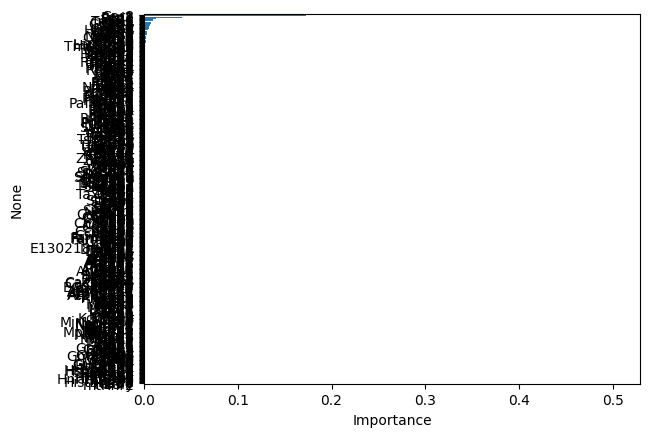

In [ ]:
fi = pd.DataFrame(data=dtr.feature_importances_, index=X_train.columns, columns= ['Importance'])\
.sort_values(by=['Importance'], ascending= False)
# And visualize
sns.barplot(data=fi, x="Importance", y=fi.index)

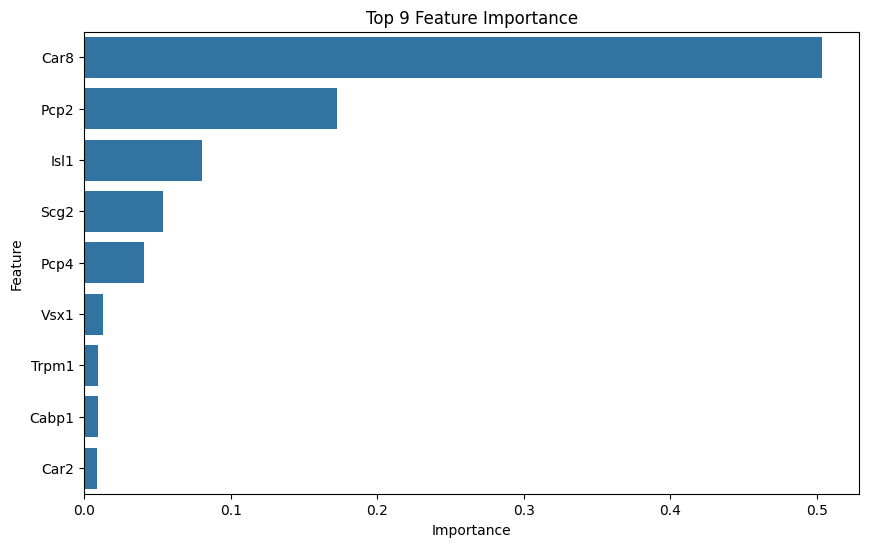

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 9 features
top_features = fi.index[:9]

# Create a new dataframe with only the top 9 features
top_fi = fi.loc[top_features]

# Visualize the top 9 features
plt.figure(figsize=(10, 6))
sns.barplot(data=top_fi, x="Importance", y=top_fi.index)
plt.title("Top 9 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Optimize the hyperparameters of the regression tree using 10 cross fold validation with
‘GridSearchCV’

In [ ]:
from sklearn.model_selection import GridSearchCV
# Lets first create a decision tree regressor
dtr = DecisionTreeRegressor()
hyperparameters = {'max_leaf_nodes': range(200,500, 5)}
dt_cv = GridSearchCV(dtr, hyperparameters,
cv= 10,
verbose = True)
dt_cv.fit(X_train, y_train)

# These variables will be available after the dt_cv object is fitted to the data
print("Best hyperparameters", dt_cv.best_params_)
print("Best score", dt_cv.best_score_)


Fitting 10 folds for each of 60 candidates, totalling 600 fits
Best hyperparameters {'max_leaf_nodes': 280}
Best score 0.5109184218350936


In [ ]:
from sklearn.ensemble import BaggingRegressor
#SOLUTIONEND
# TODO instantiate the BaggingRegressor with an DecisionTreeRegressor() as estimator. Create a bag of 12 trees. Also return the oob_score
# bagged_trees = TODO
#SOLUTIONSTART
bagged_trees = BaggingRegressor(
estimator=DecisionTreeRegressor(),
n_estimators=12,
oob_score=True)

In [ ]:
bagged_trees.fit(X_train, y_train)
#SOLUTIONEND
# Evaluate with OOB
print("--OOB--")
print("R^2",bagged_trees.oob_score_)
print("MSE", mean_squared_error(y_train,bagged_trees.oob_prediction_))
# Evaluate with the test set
y_pred = bagged_trees.predict(X_test)
# Calcualate performance metrics
print("--Test--")
print("R^2", r2_score(y_test, y_pred))
print("MSE",mean_squared_error(y_test, y_pred))

--OOB--
R^2 0.6727646846786911
MSE 32.6264754937996
--Test--
R^2 0.7171471768859543
MSE 24.749913039157228


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:1225: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(


In [ ]:
from sklearn.ensemble import RandomForestRegressor
#O Create a Random Forest regressor with 50 trees. use at most 90% of the features, return the OOB score
rf = RandomForestRegressor(
n_estimators = 50,
max_features = 0.9,
oob_score = True)

In [ ]:
# TODO fit the model to the training data
rf.fit(X_train, y_train)
# Evaluate with OOB
print("--OOB--")
print("R^2",rf.oob_score_)
print("MSE", mean_squared_error(y_train,rf.oob_prediction_))


--OOB--
R^2 0.7466842352104891
MSE 25.25644453742091


<Axes: xlabel='Importance', ylabel='None'>

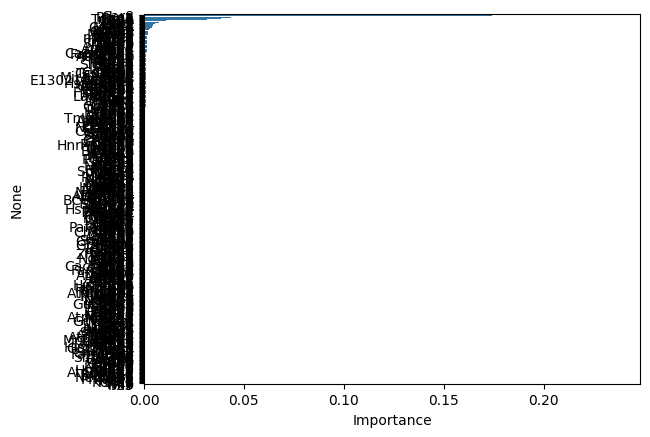

In [ ]:
 #Sort for convinience
fi = pd.DataFrame(data=rf.feature_importances_, index=X_train.columns, columns = ['Importance'])\
.sort_values(by=['Importance'], ascending= False)
# And visualize
sns.barplot(data=fi, x="Importance", y=fi.index)

<ipython-input-54-8d231870f339>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x="Importance", y=top_features.index, palette='viridis')


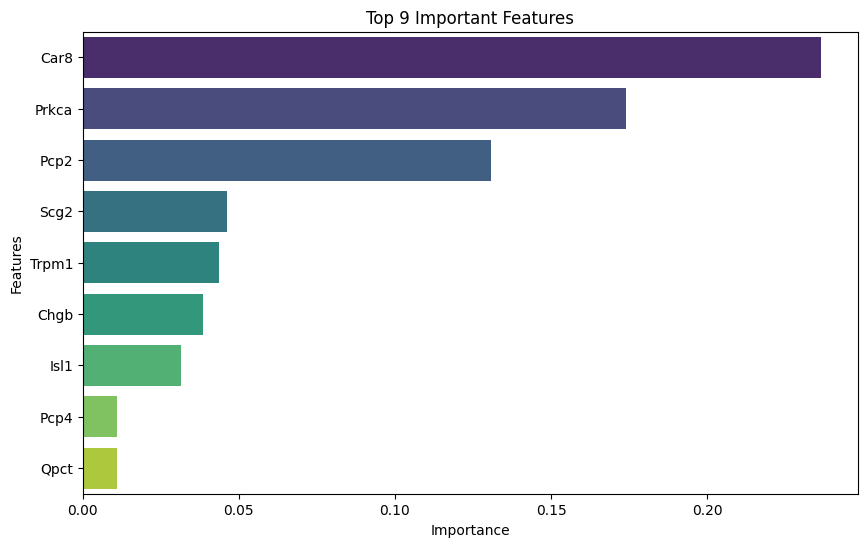

In [ ]:
# Sort the features by importance in descending order
fi_sorted = pd.DataFrame(data=rf.feature_importances_, index=X_train.columns, columns=['Importance']) \
    .sort_values(by=['Importance'], ascending=False)

# Select the top 9 features
top_n = 9
top_features = fi_sorted.head(top_n)

# Plot the barplot for the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y=top_features.index, palette='viridis')
plt.title(f'Top {top_n} Important Features')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


In [ ]:
# TODO evaluate with the test set
#SOLUTIONSTART
y_pred = rf.predict(X_test)
#SOLUTIONEND
# Calculate performance metrics
print("--Test--")
print("R^2", r2_score(y_test, y_pred))
print("MSE",mean_squared_error(y_test, y_pred))

--Test--
R^2 0.7555320174166072
MSE 21.3912


Hyperparameter tuning with Random Forests

In [ ]:
hyperparameters = {'n_estimators': [50, 200],
'max_features': [6,4]
}
# TODO implement the GridSearchCV again with cv=5, you can also specify␣ n_jobs=-1 to use all your CPU cores.
# btr_cv = TODO
#SOLUTIONSTART
btr_cv = GridSearchCV(RandomForestRegressor(),
hyperparameters,
cv= 5,
verbose = True,
n_jobs=-1)
#SOLUTIONEND
# TODO execute the exhaustive search by calling fit
#SOLUTIONSTART
btr_cv.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_features': [6, 4], 'n_estimators': [50, 200]},
             verbose=True)

In [ ]:
X_train.shape

(2606, 451)

In [ ]:
print("Best params", btr_cv.best_params_)
# Evaluate with the test set for the best estimator
y_pred = btr_cv.best_estimator_.predict(X_test)
# Calculate performance metrics
print("R^2", r2_score(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))

Best params {'max_features': 6, 'n_estimators': 200}
R^2 0.6204943433001826
MSE 33.207135420393556


<Axes: xlabel='param_n_estimators', ylabel='mean_test_score'>

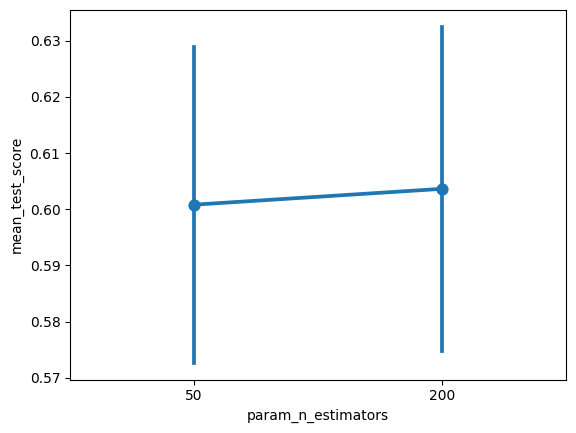

In [ ]:
cv_results = pd.DataFrame(btr_cv.cv_results_)
# Visual of the number of features vs test score
sns.pointplot(cv_results, x="param_n_estimators", y="mean_test_score")


In [ ]:
cv_results


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.548681,0.010774,0.025981,0.000950,6,50,"{'max_features': 6, 'n_estimators': 50}",0.625512,0.643800,0.626845,0.593376,0.655284,0.628963,0.020956,2
1,2.048734,0.036349,0.072348,0.003854,6,200,"{'max_features': 6, 'n_estimators': 200}",0.622704,0.648067,0.627585,0.606370,0.657712,0.632487,0.018335,1
2,0.416253,0.006757,0.023639,0.000409,4,50,"{'max_features': 4, 'n_estimators': 50}",0.565723,0.615801,0.552636,0.521748,0.607396,0.572661,0.034954,4
3,2.336965,0.610966,0.139884,0.049353,4,200,"{'max_features': 4, 'n_estimators': 200}",0.569170,0.596591,0.574846,0.542100,0.591209,0.574783,0.019210,3


SVM

svm regressor

In [ ]:
from sklearn.svm import SVR
svm_regressor = SVR(kernel='linear', decision_function_shape='ovo', random_state=42)
svm_regressor.fit(X_train_std, y_train)

SVC(decision_function_shape='ovo', kernel='linear', random_state=42)

In [ ]:

y_pred = svm_regressor.predict(X_test_std)


In [ ]:
#tttttttttttttttttttttt
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for SVR
hyperparameters = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
}

# Create an SVR model
svr_model = SVR()

# Implement GridSearchCV for SVR
svr_cv = GridSearchCV(svr_model, hyperparameters, cv=5, verbose=True, n_jobs=-1)

# Execute the exhaustive search by calling fit
svr_cv.fit(X_train_std, y_train)

# Get the best hyperparameters
best_params = svr_cv.best_params_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Predict with the best model
y_pred_svr = svr_cv.predict(X_test_std)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Hyperparameters: {'C': 1, 'kernel': 'linear'}


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for SVR
hyperparameters = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
}

# Create an SVR model
svr_model = SVR()

# Implement GridSearchCV for SVR
svr_cv = GridSearchCV(svr_model, hyperparameters, cv=5, verbose=True, n_jobs=-1)

# Execute the exhaustive search by calling fit
svr_cv.fit(X_train_std, y_train)

# Get the best hyperparameters
best_params = svr_cv.best_params_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Hyperparameters: {'C': 1, 'kernel': 'linear'}


In [ ]:
# Predict with the best model
y_pred_svr = svr_cv.predict(X_test_std)
